### **Part1 Classical ML Models (Logistic Regression, Random Forest, SVM)**

Feature matrix shape: (70000, 784)
Target vector shape : (70000,)

Pixel intensity stats:
  min: 0.0000, max: 1.0000
  mean: 0.1309, std: 0.3084



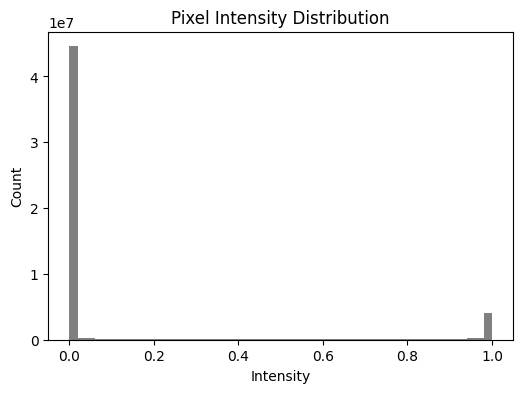

/tmp/ipython-input-44-363811518.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="viridis")


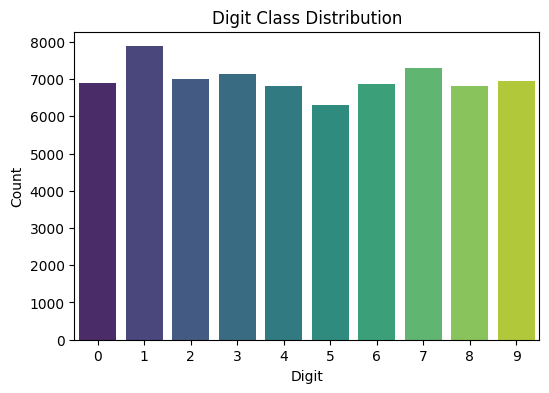

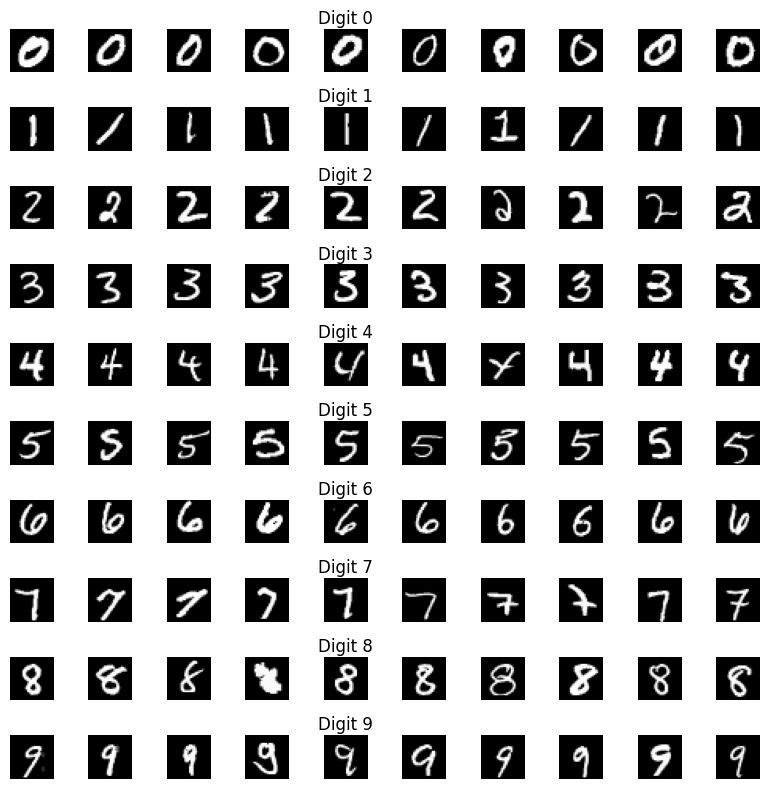

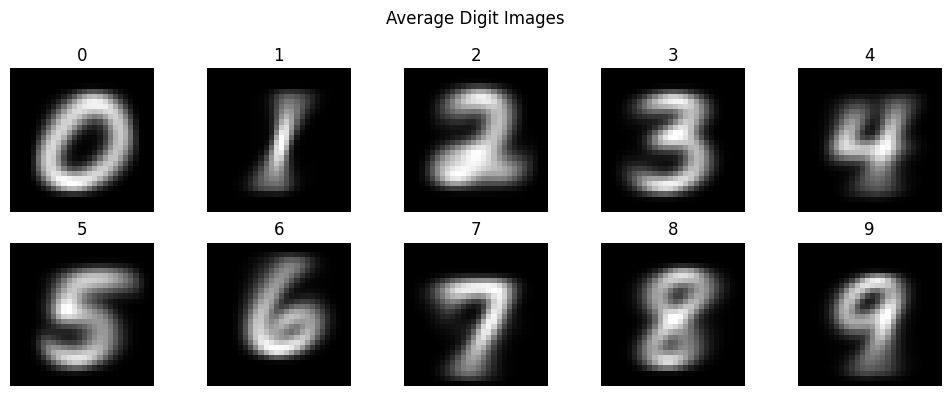

Components to retain 95% variance: 154


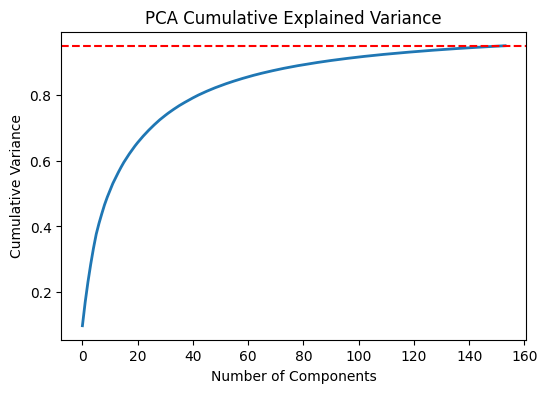

Keras MNIST shapes: x_train (60000, 28, 28), x_test (10000, 28, 28)

PCA reduced dims: 784 → 330


=== Logistic (SGD) ===
Train Acc: 0.8985  Test Acc: 0.8954

Train Classification Report:
              precision    recall  f1-score   support

           0     0.9749    0.9444    0.9594      5522
           1     0.9755    0.9529    0.9640      6302
           2     0.9395    0.8771    0.9072      5592
           3     0.9372    0.8444    0.8884      5713
           4     0.9427    0.8894    0.9153      5459
           5     0.8942    0.8350    0.8636      5050
           6     0.9566    0.9407    0.9486      5501
           7     0.9555    0.9098    0.9321      5834
           8     0.6235    0.9355    0.7483      5460
           9     0.9222    0.8453    0.8821      5567

    accuracy                         0.8985     56000
   macro avg     0.9122    0.8975    0.9009     56000
weighted avg     0.9139    0.8985    0.9024     56000

Test Classification Report:
              precision  

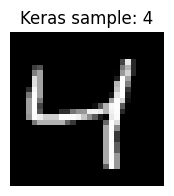

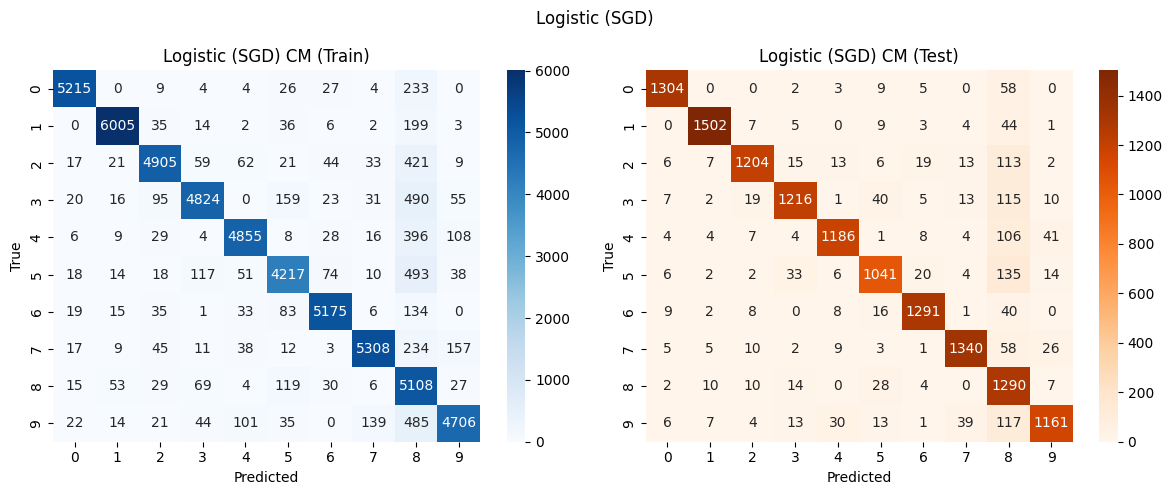


=== Random Forest ===
Train Acc: 1.0000  Test Acc: 0.9349

Train Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      5522
           1     1.0000    1.0000    1.0000      6302
           2     1.0000    1.0000    1.0000      5592
           3     1.0000    1.0000    1.0000      5713
           4     1.0000    1.0000    1.0000      5459
           5     1.0000    1.0000    1.0000      5050
           6     1.0000    1.0000    1.0000      5501
           7     1.0000    1.0000    1.0000      5834
           8     1.0000    1.0000    1.0000      5460
           9     1.0000    1.0000    1.0000      5567

    accuracy                         1.0000     56000
   macro avg     1.0000    1.0000    1.0000     56000
weighted avg     1.0000    1.0000    1.0000     56000

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9503    0.9841    0.9669      1381
           1   

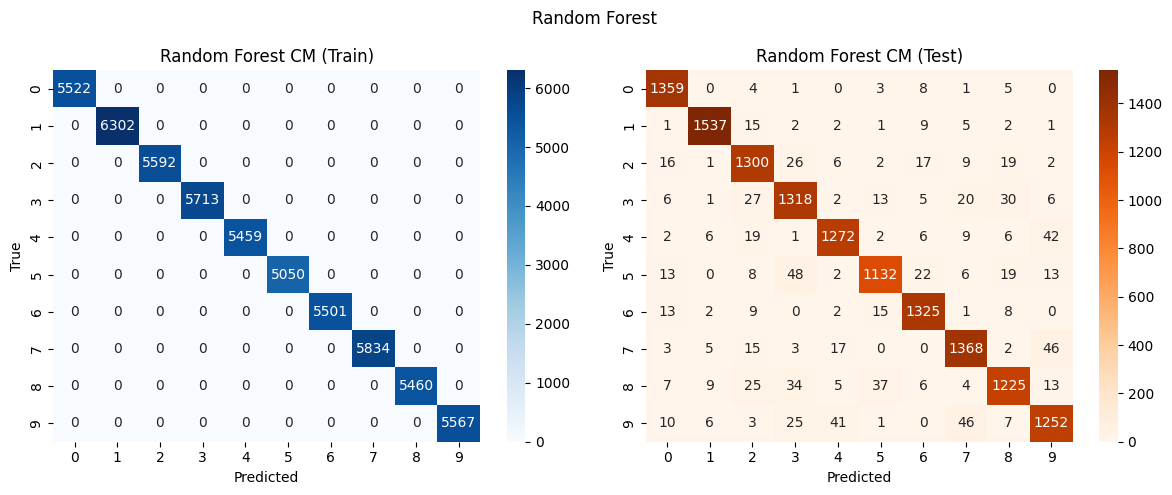


=== SVM (RBF) ===
Train Acc: 0.9851  Test Acc: 0.9659

Train Classification Report:
              precision    recall  f1-score   support

           0     0.9922    0.9937    0.9929      5522
           1     0.9863    0.9924    0.9893      6302
           2     0.9856    0.9886    0.9871      5592
           3     0.9828    0.9793    0.9811      5713
           4     0.9805    0.9874    0.9839      5459
           5     0.9843    0.9824    0.9833      5050
           6     0.9924    0.9916    0.9920      5501
           7     0.9839    0.9829    0.9834      5834
           8     0.9820    0.9804    0.9812      5460
           9     0.9808    0.9714    0.9761      5567

    accuracy                         0.9851     56000
   macro avg     0.9851    0.9850    0.9850     56000
weighted avg     0.9851    0.9851    0.9851     56000

Test Classification Report:
              precision    recall  f1-score   support

           0     0.9758    0.9913    0.9835      1381
           1     0.

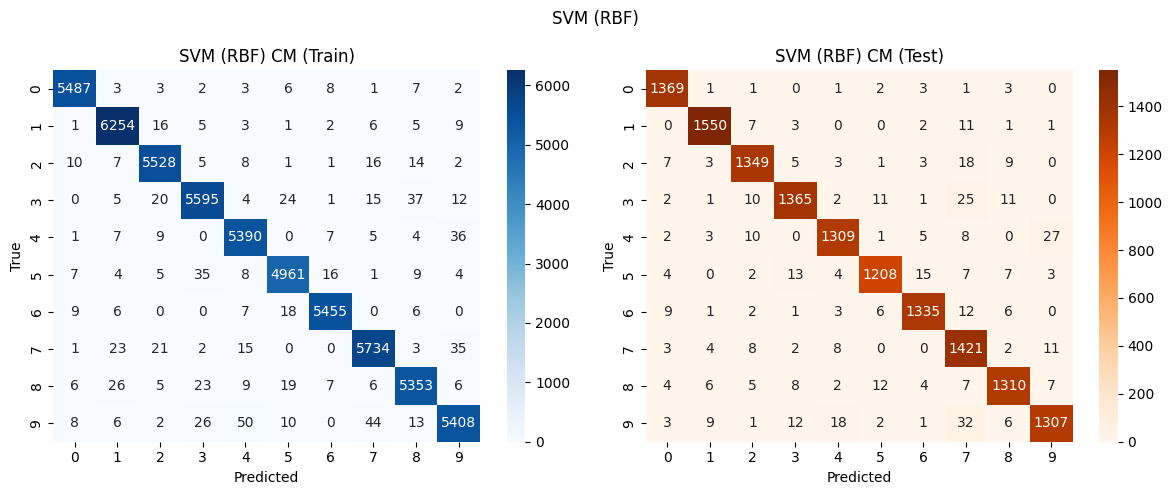


=== Combined Evaluation Summary ===
                Train Acc  Test Acc  Train Prec  Test Prec  Train Rec  Test Rec  Train F1  Test F1
Model                                                                                             
Logistic (SGD)     0.8985    0.8954      0.9122     0.9096     0.8975    0.8941    0.9009   0.8976
Random Forest      1.0000    0.9349      1.0000     0.9345     1.0000    0.9340    1.0000   0.9341
SVM (RBF)          0.9851    0.9659      0.9851     0.9663     0.9850    0.9656    0.9850   0.9658


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# Load the mnist data
X_df, y_ser = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X_df.to_numpy().astype(np.float32) / 255.0   # (70000, 784)
y = y_ser.to_numpy().astype(int)                # (70000,)

#EDA
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape : {y.shape}\n")

# Pixel intensity stats
print("Pixel intensity stats:")
print(f"  min: {X.min():.4f}, max: {X.max():.4f}")
print(f"  mean: {X.mean():.4f}, std: {X.std():.4f}\n")

# Pixel intensity distribution
plt.figure(figsize=(6,4))
plt.hist(X.ravel(), bins=50, color='gray')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity"); plt.ylabel("Count")
plt.show()

# Class distribution
counts = pd.Series(y).value_counts().sort_index()
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette="viridis")
plt.title("Digit Class Distribution")
plt.xlabel("Digit"); plt.ylabel("Count")
plt.show()

# 10 random samples per digit
fig, axes = plt.subplots(10, 10, figsize=(8,8))
for digit in range(10):
    idxs = np.where(y == digit)[0]
    samp = np.random.choice(idxs, 10, replace=False)
    for i, idx in enumerate(samp):
        ax = axes[digit, i]
        ax.imshow(X[idx].reshape(28,28), cmap='gray')
        ax.axis('off')
        if i == 4:
            ax.set_title(f"Digit {digit}", pad=4)
plt.tight_layout()
plt.show()

# Average image per class
mean_imgs = np.array([X[y==d].mean(axis=0).reshape(28,28) for d in range(10)])
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for d, ax in enumerate(axes.ravel()):
    ax.imshow(mean_imgs[d], cmap='gray')
    ax.set_title(f"{d}")
    ax.axis('off')
plt.suptitle("Average Digit Images")
plt.tight_layout()
plt.show()

# PCA explained variance
pca_full = PCA(n_components=0.95, svd_solver='full').fit(X)
print(f"Components to retain 95% variance: {pca_full.n_components_}")
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), lw=2)
plt.axhline(0.95, color='red', linestyle='--')
plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Components"); plt.ylabel("Cumulative Variance")
plt.show()

# Sample from Keras dataset
(xk_tr, yk_tr), (xk_te, yk_te) = tf.keras.datasets.mnist.load_data()
plt.figure(figsize=(2,2))
plt.imshow(xk_tr[2], cmap='gray')
plt.title(f"Keras sample: {yk_tr[2]}")
plt.axis('off')
print(f"Keras MNIST shapes: x_train {xk_tr.shape}, x_test {xk_te.shape}\n")


# Preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_tr_s = scaler.transform(X_train)
X_te_s = scaler.transform(X_test)

pca = PCA(n_components=0.95, svd_solver='full').fit(X_tr_s)
X_tr_p = pca.transform(X_tr_s)
X_te_p = pca.transform(X_te_s)
print(f"PCA reduced dims: {X_tr_s.shape[1]} → {X_tr_p.shape[1]}\n")


# Defining the models
models = {
    'Logistic (SGD)': SGDClassifier(
        loss='log_loss', max_iter=1000, tol=1e-3, random_state=42, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', gamma='scale', random_state=42
    )
}


# Train and evaluate the models
summary_rows = []
for name, mdl in models.items():
    print(f"\n=== {name} ===")
    mdl.fit(X_tr_p, y_train)


    y_tr_pred = mdl.predict(X_tr_p)
    y_te_pred = mdl.predict(X_te_p)


    tr_acc = accuracy_score(y_train, y_tr_pred)
    te_acc = accuracy_score(y_test,  y_te_pred)
    print(f"Train Acc: {tr_acc:.4f}  Test Acc: {te_acc:.4f}")


    print("\nTrain Classification Report:")
    print(classification_report(y_train, y_tr_pred, digits=4))
    print("Test Classification Report:")
    print(classification_report(y_test, y_te_pred, digits=4))


    tr_prec, tr_rec, tr_f1, _ = precision_recall_fscore_support(
        y_train, y_tr_pred, average='macro'
    )
    te_prec, te_rec, te_f1, _ = precision_recall_fscore_support(
        y_test, y_te_pred, average='macro'
    )
    summary_rows.append({
        'Model':      name,
        'Train Acc':  tr_acc,
        'Test Acc':   te_acc,
        'Train Prec': tr_prec,
        'Test Prec':  te_prec,
        'Train Rec':  tr_rec,
        'Test Rec':   te_rec,
        'Train F1':   tr_f1,
        'Test F1':    te_f1
    })


    cm_tr = confusion_matrix(y_train, y_tr_pred)
    cm_te = confusion_matrix(y_test,  y_te_pred)
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.heatmap(cm_tr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{name} CM (Train)')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    sns.heatmap(cm_te, annot=True, fmt='d', cmap='Oranges', ax=axes[1])
    axes[1].set_title(f'{name} CM (Test)')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    plt.suptitle(name)
    plt.tight_layout()
    plt.show()


df_summary = pd.DataFrame(summary_rows).set_index('Model')
print("\n=== Combined Evaluation Summary ===")
print(df_summary.to_string(float_format="%.4f"))


### **Part 2 Convolutional Neural Network (CNN)**

Epoch 1/20
422/422 - 35s - 82ms/step - accuracy: 0.8775 - loss: 0.4040 - val_accuracy: 0.8798 - val_loss: 0.3480 - learning_rate: 1.0000e-03
Epoch 2/20
422/422 - 33s - 78ms/step - accuracy: 0.9582 - loss: 0.1427 - val_accuracy: 0.9862 - val_loss: 0.0501 - learning_rate: 1.0000e-03
Epoch 3/20
422/422 - 32s - 77ms/step - accuracy: 0.9691 - loss: 0.1024 - val_accuracy: 0.9872 - val_loss: 0.0460 - learning_rate: 1.0000e-03
Epoch 4/20
422/422 - 33s - 79ms/step - accuracy: 0.9745 - loss: 0.0872 - val_accuracy: 0.9897 - val_loss: 0.0356 - learning_rate: 1.0000e-03
Epoch 5/20
422/422 - 40s - 94ms/step - accuracy: 0.9772 - loss: 0.0773 - val_accuracy: 0.9900 - val_loss: 0.0383 - learning_rate: 1.0000e-03
Epoch 6/20
422/422 - 41s - 98ms/step - accuracy: 0.9788 - loss: 0.0686 - val_accuracy: 0.9908 - val_loss: 0.0368 - learning_rate: 1.0000e-03
Epoch 7/20
422/422 - 32s - 77ms/step - accuracy: 0.9828 - loss: 0.0562 - val_accuracy: 0.9922 - val_loss: 0.0352 - learning_rate: 5.0000e-04
Epoch 8/20
42

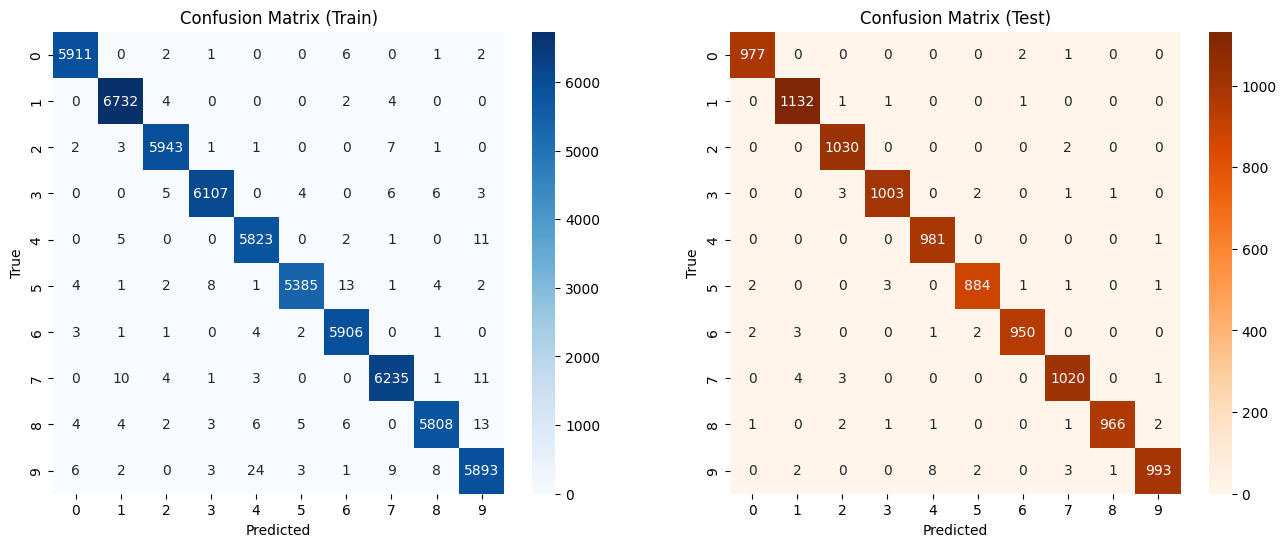

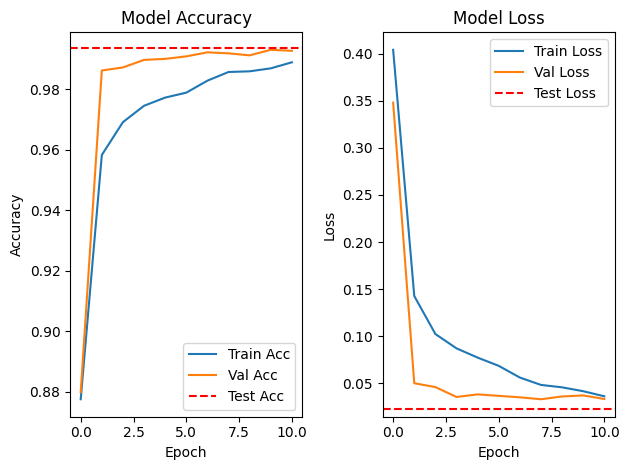

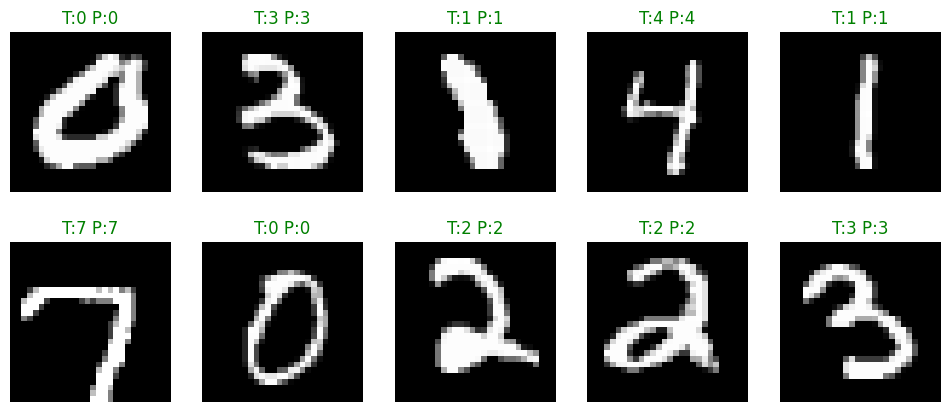

Model saved to mnist_cnn.h5


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Conv2D, BatchNormalization,
    MaxPooling2D, Flatten,
    Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess the data (normalization & reshaping)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

# Build the CNN with explicit Input layer
cnn = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Compile & train
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
]
history = cnn.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=callbacks,
    verbose=2
)

# Evaluate on both train and test sets
train_loss, train_acc = cnn.evaluate(x_train, y_train, verbose=0)
test_loss,  test_acc  = cnn.evaluate(x_test,  y_test,  verbose=0)
print(f"\nTrain accuracy: {train_acc:.4f}    Test accuracy: {test_acc:.4f}")

# Generate predictions
y_train_pred = np.argmax(cnn.predict(x_train), axis=1)
y_test_pred  = np.argmax(cnn.predict(x_test),  axis=1)

# Classification reports
print("\nClassification Report — Train:")
print(classification_report(y_train, y_train_pred, digits=4))
print("Classification Report — Test:")
print(classification_report(y_test, y_test_pred, digits=4))

# Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test  = confusion_matrix(y_test,  y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix (Train)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1], cmap='Oranges')
axes[1].set_title('Confusion Matrix (Test)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.show()

# Visualization
#plt.figure(figsize=(12,4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.axhline(test_acc, color='red', linestyle='--', label='Test Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.axhline(test_loss, color='red', linestyle='--', label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Few predictions (correct vs incorrect)
fig, axes = plt.subplots(2, 5, figsize=(12,5))
indices = np.random.choice(len(x_test), 10, replace=False)
for ax, idx in zip(axes.flat, indices):
    ax.imshow(x_test[idx].reshape(28,28), cmap='gray')
    title_color = 'green' if y_test[idx] == y_test_pred[idx] else 'red'
    ax.set_title(f'T:{y_test[idx]} P:{y_test_pred[idx]}', color=title_color)
    ax.axis('off')
plt.show()

# Save the trained model
cnn.save('mnist_cnn.h5')
print("Model saved to mnist_cnn.h5")